In [1]:
import numpy as np
from numpy import linalg as LA
import matplotlib.mlab as mlab
import matplotlib.pyplot as plt
import scipy

from scipy import linalg
from scipy import stats
from pylab import * 
%matplotlib inline
from scipy.optimize import curve_fit

In [2]:
import matplotlib.pyplot as plt
import matplotlib.mlab as mlab
%matplotlib inline
import numpy as np
from numpy import linalg as LA
from scipy import linalg
from scipy import stats
from pylab import * 
#from tempfile import TemporaryFile
P = open("/cueva/Susana/Susana_josePC/Prices.txt","rb")
S = open("/cueva/Susana/Susana_josePC/Symbols.txt","r")
D = open("/cueva/Susana/Susana_josePC/Dates.txt","r")
G = open("/cueva/Susana/Susana_josePC/Gics.txt","r")
from __future__ import division 

In [3]:
s=[]
lines=S.readlines()
S.close()
for line in lines:
	values = line.split()
	s.append(values[0])
lensymbols=len(s)

d=[]
lines=D.readlines()
D.close() 
for line in lines:
	values = line.split()
	d.append(values[0])
#print type(values)	
lendates=len(d)

g=[]
lines=G.readlines()
G.close()
for line in lines:
	values = line.split()
	g.append(values[0])
    
Prices=np.loadtxt("Prices.txt")      
lenPrices=len(Prices)

In [4]:
#----- Rendimientos---

Returns=[]

for i in range(lensymbols):
	Returns.append([])
	for j in range(1,lendates):
		r=(Prices[i][j]/Prices[i][j-1])-1
                Returns[-1].append(r)
Returns=np.asarray(Returns)
#print len(Returns)

In [6]:
Cmean=[]
#CPmean=[]
for i in range(262):
  
    Creal=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%i)
    #CP=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorrPM%dq1.05.dat"%i)
    cm=Creal.mean()
    #cpm=CP.mean()
    Cmean.append(cm)
    #CPmean.append(cpm)


In [7]:
def map_level(f, item, level):
    if level == 0:
        return f(item)
    else:
        return [map_level(f, i, level - 1) for i in item]

In [8]:
np.random.seed(9)

In [14]:
nummat=2000
numVentana=262
N=293
T=44
e=.05
q=1+e 
k1=23
k2=21
k3=39
k4=46
k5=26
k6=29
k7=47
k8=33
k9=5
k10=24
q1=q+1
C = np.empty((N,N))
Cdiag = np.empty((N,N))
Cq = np.empty((N,N))
Corr = np.zeros((N,N))
Corrsqr = np.empty((N,N))
CWOEsectores=np.empty((numVentana,N))

#vtotal=np.zeros(((nummat,N,N)))   
v1total=np.empty(((nummat,N,N)))   
w1total=np.empty((nummat,N))
ks=[0,k1,k2,k3,k4,k5,k6,k7,k8,k9,k10]

In [38]:
#lista del tamaño de bloques
enes=[]
ene=0
for i in ks:
    ene+=i
    enes.append(ene)
  
    
   

269

In [44]:
#hacer la matriz de corr de solo bloques
N=293
T=44
e=.05
q=1+e 
Corr1 = np.zeros((N,N))
Corr1[:enes[0],:enes[0]]=Creal[:enes[0],:enes[0]].mean()
for i in xrange(len(enes)-1):
    Corr1[enes[i]:enes[i+1], enes[i]:enes[i+1]]=Creal[enes[i]:enes[i+1], enes[i]:enes[i+1]].mean()
for i in xrange(N):
    for j in xrange(i,N):
        if i==j:
            Corr1[i][j]=1
#Corrsqr=np.real(scipy.linalg.sqrtm(Corr))

In [84]:
#correlacion promedio fuera de los sectores
Cpromnosec=[]

Cpromnosec.append(Creal[:enes[0], enes[0]:].sum())
numnosec=Creal[:enes[0], enes[0]:].size
for i in xrange(len(enes)-1):
    Cpromnosec.append(Creal[enes[i]:enes[i+1], enes[i+1]:].sum())
    numnosec+=Creal[enes[i]:enes[i+1], enes[i+1]:].size
corrnosec=sum(Cpromnosec)/numnosec



In [92]:
Corr1[:enes[0], enes[0]:]=corrnosec
Corr1[enes[0]:, :enes[0]]=corrnosec
for i in xrange(len(enes)-1):
    Corr1[enes[i]:enes[i+1], enes[i+1]:]=corrnosec
    Corr1[ enes[i+1]:,enes[i]:enes[i+1]]=corrnosec

In [89]:
corrnosec

0.38427956439280458

In [76]:
n1=k1
n2=k1+k2
n3=k1+k2+k3
n4=k1+k2+k3+k4
n5=k1+k2+k3+k4+k5
n6=k1+k2+k3+k4+k5+k6
n7=k1+k2+k3+k4+k5+k6+k7
n8=k1+k2+k3+k4+k5+k6+k7+k8
n9=k1+k2+k3+k4+k5+k6+k7+k8+k9
n10=k1+k2+k3+k4+k5+k6+k7+k8+k9+k10

In [47]:
###  matriz de Xi corr ###
N=293
T=44
e=.05
q=1+e 

k1=23
k2=21
k3=39
k4=46
k5=26
k6=29
k7=47
k8=33
k9=5
k10=24
q1=q+1
Corr = np.zeros((N,N))
Corr[:k1,:k1]=Creal[:n1,:n1].mean()
Corr[n1:n2,n1:n2]=Creal[n1:n2,n1:n2].mean()
Corr[n2:n3,n2:n3]=Creal[n2:n3,n2:n3].mean()
Corr[n3:n4,n3:n4]=Creal[n3:n4,n3:n4].mean()
Corr[n4:n5,n4:n5]=Creal[n4:n5,n4:n5].mean()
Corr[n5:n6,n5:n6]=Creal[n5:n6,n5:n6].mean()
Corr[n6:n7,n6:n7]=Creal[n6:n7,n6:n7].mean()
Corr[n7:n8,n7:n8]=Creal[n7:n8,n7:n8].mean()
Corr[n8:n9,n8:n9]=Creal[n8:n9,n8:n9].mean()
Corr[n9:n10,n9:n10]=Creal[n9:n10,n9:n10].mean()
for i in xrange(N):
    for j in xrange(i,N):
        if i==j:
            Corr[i][j]=1


Corrsqr=np.real(scipy.linalg.sqrtm(Corr))

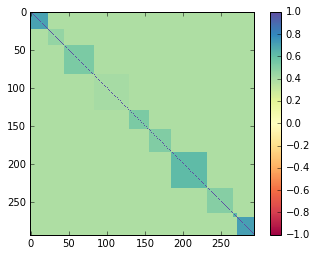

In [93]:
#plt.imshow(Corr,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
#plt.colorbar()
im=plt.imshow(Corr1,interpolation='nearest',cmap=plt.get_cmap("Spectral"))
plt.colorbar()
im.set_clim(-1.0, 1.0)

In [27]:
#### matriz wishart ####
W=[]
M1 = 1 * np.random.randn(N, T) + 0
#print M1

####### normalizando el renglon ######
for i in xrange(N):
    mean=np.mean(M1[i])
    dstd=np.std(M1[i])
    M1[i]=(M1[i]-mean)/dstd

##### haciendo la matriz de corr(wishart correlacionado) ######

Corrsqr=np.real(scipy.linalg.sqrtm(Corr))
CorrsqrM1=np.dot(Corrsqr,M1)
#M2Corrsqr=np.dot(M2,Corrsqr)
M2Corrsqr=np.transpose(CorrsqrM1)

C=np.dot(CorrsqrM1,M2Corrsqr)
C=C/T


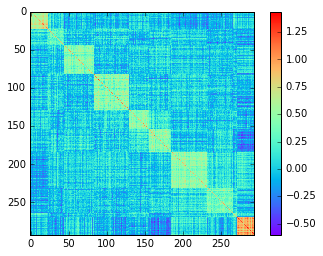

In [28]:
plt.imshow(C,interpolation='nearest',cmap=plt.get_cmap('rainbow'))
plt.colorbar()

In [83]:
for ii in range(262):
    Wmean=[]
    Creal=np.loadtxt("/cueva/Susana/SusanaDos/SYP-q1.05/MatrizCorr%d.dat"%ii)
    Corr = np.zeros((N,N))
    Corr[:k1,:k1]=Creal[:n1,:n1].mean()
    Corr[n1:n2,n1:n2]=Creal[n1:n2,n1:n2].mean()
    Corr[n2:n3,n2:n3]=Creal[n2:n3,n2:n3].mean()
    Corr[n3:n4,n3:n4]=Creal[n3:n4,n3:n4].mean()
    Corr[n4:n5,n4:n5]=Creal[n4:n5,n4:n5].mean()
    Corr[n5:n6,n5:n6]=Creal[n5:n6,n5:n6].mean()
    Corr[n6:n7,n6:n7]=Creal[n6:n7,n6:n7].mean()
    Corr[n7:n8,n7:n8]=Creal[n7:n8,n7:n8].mean()
    Corr[n8:n9,n8:n9]=Creal[n8:n9,n8:n9].mean()
    Corr[n9:n10,n9:n10]=Creal[n9:n10,n9:n10].mean()
    for i in xrange(N):
        for j in xrange(i,N):
            if i==j:
                Corr[i][j]=1


    Corrsqr=np.real(scipy.linalg.sqrtm(Corr))
    
    for matriz in xrange(nummat):
        #### matriz wishart ####

        M1 = 1 * np.random.randn(N, T) + 0	
        #print M1


        ####### normalizando el renglon ######
        #M1=[(s-s.mean())/s.std() for s in M1]
        #M1=np.asarray(M1)

        ###### transpuesta #####
        #M2=np.transpose(M1)        


        ##### haciendo la matriz de corr(wishart correlacionado) ######
        #Corrsqr=np.real(scipy.linalg.sqrtm(Corr))

        CorrsqrM1=np.dot(Corrsqr,M1)

        ###normalizando Xi corr por M1

        CorrsqrM1=[(s-s.mean())/s.std() for s in CorrsqrM1]
        CorrsqrM1=np.asarray(CorrsqrM1)
        #######

        M2Corrsqr=np.transpose(CorrsqrM1)


        C=np.dot(CorrsqrM1,M2Corrsqr)
        C=C/T
        ###### diagonalizando C #########
        #w, v = LA.eigh(C)
        #W=w

        #vtotal[matriz]=v
        ##### power mapping #####

        Cq=map_level(lambda x: abs(x)**(q1)/x, C, 2)
        Cq=np.asarray(Cq)
        ### diagonalizando Cq ###

        w1, v1 = LA.eigh(Cq)
        
        w1total[matriz]=w1 
        v1total[matriz]=v1
    for jj in xrange(N):
        Wmean.append(w1total[:,jj].mean())
    Wmean=np.asarray(Wmean)
    CWOEsectores[ii]=Wmean
    #Wmean=[]

In [54]:
len (CWOEsectores[0])
#CWOEvalores

293

In [84]:
#guardando los evalores del WOE

#fil= open("/cueva/Susana/SusanaDos/CWOEevalores/CWOEvalorq%.2f.dat"%(q),"w")
#for renglon in xrange(numVentana):
#   for item in CWOEvalores[renglon]:
#        fil.write(str(item)+" ")
#    fil.write("\n")
#fil.close
titulo="/cueva/Susana/SusanaDos/CWOEevalores/CWOEsector2q%.2f"%(q)
np.save(titulo,CWOEsectores)

In [67]:
WW=np.load("/cueva/Susana/SusanaDos/CWOEevalores/CWOEsectorq1.05.npy")
len(WW)

262

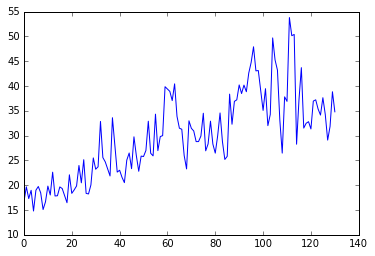

In [68]:
#grafica de evalor mayor 
WWmax=[]
for i in xrange(0,262,2):
    WWmax.append(np.max(WW[i]))
plt.plot(WWmax)    

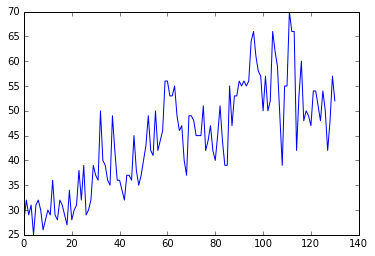

In [69]:
#numeros negativos
WWnega=[]
for i in xrange(0,262,2):
    suma=0
    for valor in WW[i][:249]:
        if valor < 1e-14:
            suma+=1
    WWnega.append(suma)
plt.plot(WWnega)    
        

In [70]:
#calculando los momentos

m1=[]
m2=[]
for i in xrange(0,262,2):
    mo1=np.mean(WW[i][:249])
    mo2=np.var(WW[i][:249])
    m1.append(mo1)
    m2.append(mo2)

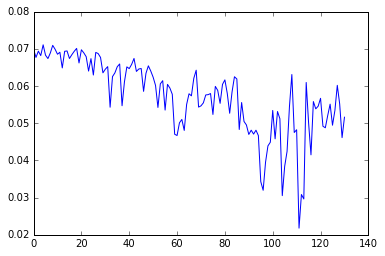

In [71]:
plt.plot(m1)

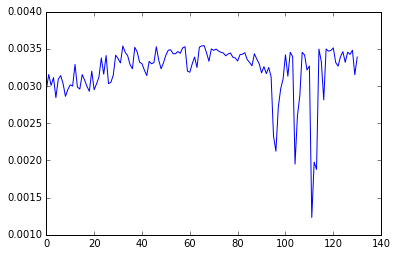

In [73]:
plt.plot(m2)

In [7]:
matriz=np.array([[2,2,2],[1,1,1.5]])
matriz2=[]
for jj in xrange(3):  
    matriz2.append( matriz[:,jj].mean())
matriz2    

[1.5, 1.5, 1.75]

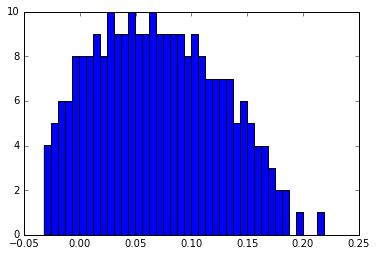

In [79]:
plt.hist(WW[22][:N-T+1],40);

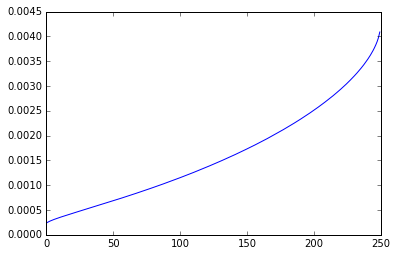

In [54]:
plt.plot(WW[223][:N-T+1])

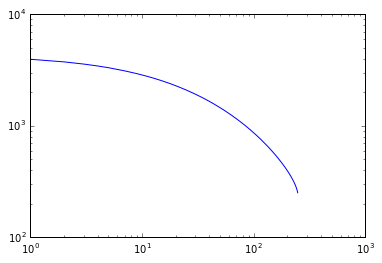

In [56]:
#zipfś law
num=np.arange(249)
plt.loglog(1/(WW[223][0:249]))
#num

 #evv==vtotal[2][:,250]
 #MATT=np.dot(C,evv)
 #print MATT/ev

In [43]:
WW[20][0]


-0.031544320905551967

In [40]:
#vtotal[:,:][:,N-1]==vtotal[:,N-1]

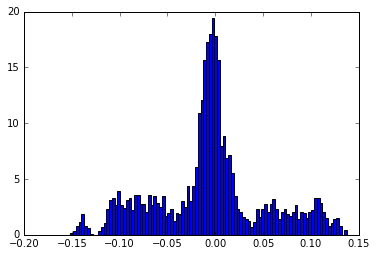

In [71]:
altura,cajas,ignorar=plt.hist((vtotal[:,:,N-1]).flatten(),100, normed=1,histtype='bar')

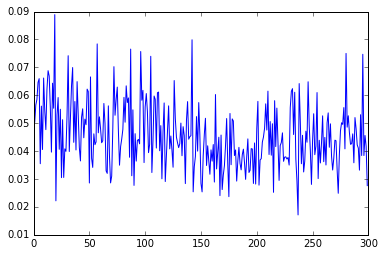

In [72]:
vtmn=(abs(vtotal[:,:,201])).mean(axis=0)
plt.plot(vtmn)

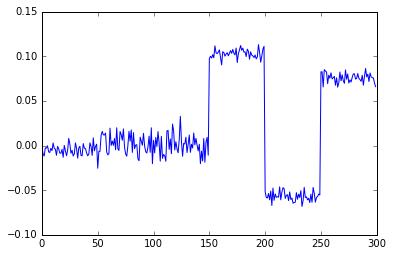

In [73]:
plt.plot(vtotal[3,:,N-1])

In [10]:
### ajustando una gaussina
Centrocajas=np.zeros(len(altura))
ds=cajas[1]-cajas[0]

#    print ds
for i in xrange(0,len(cajas)-1):
    Centrocajas[i]=cajas[i]+ds/2

#model function
def f(x, a, b,c):
    return a*np.exp(-((x-b)**2)/(2*c**2))

# Do the fit
popt, pcov = curve_fit(f, Centrocajas, altura, [1.0, 1.0,1.0])
# Plot data


# Plot fit curve
fit_x = np.linspace(-.25, .25, 200) 
#plt.plot(fit_x, f(fit_x, *popt),'r-', label="Fitted Curve")
#plt.legend()
#print popt

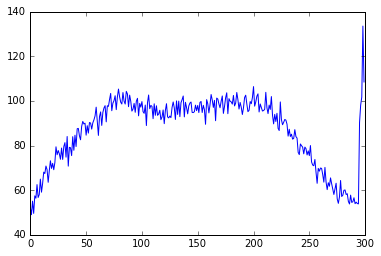

In [74]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

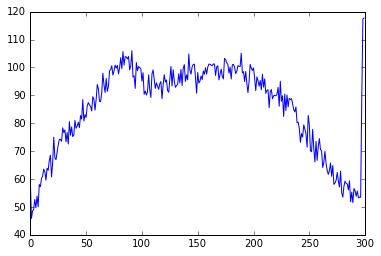

In [55]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

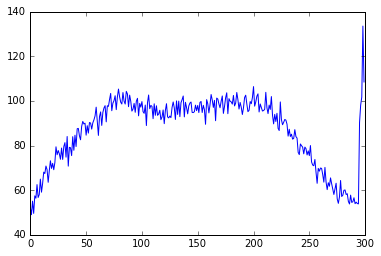

In [75]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

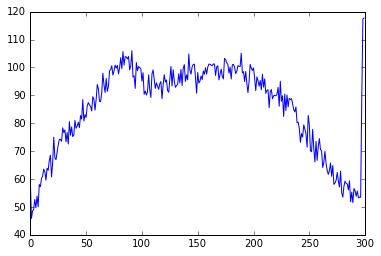

In [54]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

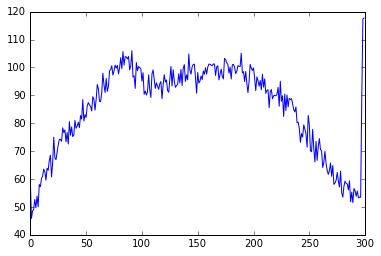

In [53]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

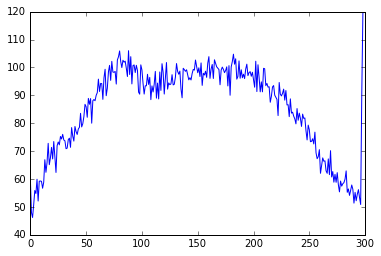

In [14]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

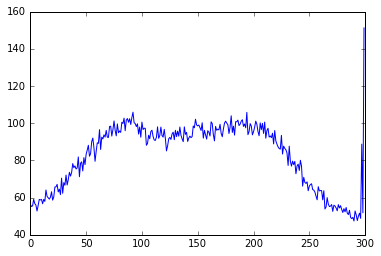

In [33]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(v1total**4,axis=1)
vIPR=1/vIPR
#vIPRmn=vIPR.mean(axis=0)

plt.plot(vIPR.mean(axis=0))

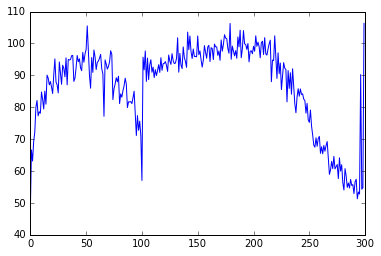

In [66]:
######### calculando lal intensidad (IPR)#########
vIPR=np.sum(vtotal**4,axis=1)
vIPR=1/vIPR
plt.plot(vIPR.mean(axis=0))

In [17]:
plt.plot(vIPR[10])

IndexError: index 10 is out of bounds for axis 0 with size 10

In [18]:
sumarray=[]
for k in xrange(nummat):
    suma=[]
    for i in xrange(N):
        sumvv=0
        for j in xrange(N-T+1,N):
            v1v=np.dot(v1total[k,:,i],vtotal[k,:,j])
            sumvv+=(v1v)**2  
        suma.append(sumvv)
    sumarray.append(suma)
    
#plt.plot(sum[:])


In [11]:
sumarray=np.asarray(sumarray)
sumn=sumarray.mean(axis=0)

In [19]:
plt.semilogy(sumn[:])

NameError: name 'sumn' is not defined